# Give Me Some Credit — Loan Default Prediction

**Goal**: Build a binary classification model that predicts whether a borrower will experience serious delinquency (90+ days past due) within the next two years.

**Data**: Kaggle "Give Me Some Credit" competition dataset (`cs-training.csv`, 150,000 rows)

**Approach**: EDA to diagnose data issues → evidence-based cleaning → Logistic Regression baseline → XGBoost → SHAP interpretation

**Key metric**: Since the target is imbalanced (6.7% vs 93.3%), we use **AUC-ROC** as the primary metric instead of accuracy.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import shap

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Data Loading and Initial Diagnosis

First, let's check the target distribution and missing value status.


In [2]:
df_raw = pd.read_csv('cs-training.csv', index_col=0)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print("=== Target distribution (checking class imbalance) ===")
print(df_raw['SeriousDlqin2yrs'].value_counts(normalize=True))


=== Target distribution (checking class imbalance) ===
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [4]:
print("=== Missing values ===")
print(df_raw.isna().sum()[df_raw.isna().sum() > 0])


=== Missing values ===
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


**Finding 1**: The target is heavily imbalanced at 6.7% : 93.3%. → We should use AUC-ROC instead of accuracy as the primary metric.

**Finding 2**: `MonthlyIncome` (~20%) and `NumberOfDependents` (~2.6%) have missing values.


### 1-1. Outlier diagnosis: age, sentinel codes in delinquency columns, DebtRatio/Revolving extreme values

In [5]:
# Check age = 0 (a physically impossible value)
print("Rows with age=0:", (df_raw['age'] == 0).sum())


Rows with age=0: 1


In [6]:
# Check 96/98 codes in the delinquency columns
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]
mask_sentinel = (df_raw[delinquency_cols] >= 96).any(axis=1)
print("Rows with a 96/98 code:", mask_sentinel.sum())
print("Default rate in this group:", df_raw.loc[mask_sentinel, 'SeriousDlqin2yrs'].mean())
print("Overall average default rate:", df_raw['SeriousDlqin2yrs'].mean())


Rows with a 96/98 code: 269
Default rate in this group: 0.5464684014869888
Overall average default rate: 0.06684


**Finding 3**: There are 269 rows where 96/98 appear simultaneously across all three delinquency columns. The default rate in this group is **54.6%**, more than 8x the overall average (6.7%). These look like sentinel codes (flags for special/unusual cases) rather than genuine delinquency counts. → We'll treat them as missing and impute, but preserve the information as a flag variable so it isn't lost.

In [7]:
# Check the relationship between DebtRatio extreme values and missing income
thresh = df_raw['DebtRatio'].quantile(0.99)
extreme = df_raw[df_raw['DebtRatio'] > thresh]
print(f"Share with missing income among top 1% DebtRatio (>{thresh:.0f}): {extreme['MonthlyIncome'].isna().mean():.1%}")
print(f"Share with missing income overall: {df_raw['MonthlyIncome'].isna().mean():.1%}")


Share with missing income among top 1% DebtRatio (>4979): 94.3%
Share with missing income overall: 19.8%


**Finding 4 (important)**: 94% of the extreme `DebtRatio` values overlap with missing `MonthlyIncome`. Since `DebtRatio = debt / income`, a missing/near-zero income denominator explains the exploding ratio. These two issues are not independent — it makes more sense to **impute missing income first, then cap DebtRatio**, rather than treating them separately.

## 2. Data Cleaning

Based on the diagnosis above, we apply the following steps in order:

1. Remove rows with `age = 0`
2. Delinquency columns with 96/98 → treat as missing, impute with median, and create a `had_sentinel_code` flag
3. `MonthlyIncome` missing → impute with median + `income_missing` flag
4. `NumberOfDependents` missing → impute with 0 + `dependents_missing` flag
5. `DebtRatio`, `RevolvingUtilizationOfUnsecuredLines` → cap at the 99.5th percentile (winsorize)


In [8]:
df = df_raw.copy()

# 1) Remove age=0
df = df[df['age'] > 0].copy()

# 2) Handle 96/98 sentinel codes
df['had_sentinel_code'] = (df[delinquency_cols] >= 96).any(axis=1).astype(int)
for col in delinquency_cols:
    df.loc[df[col] >= 96, col] = np.nan
    df[col] = df[col].fillna(df[col].median())

# 3) Handle MonthlyIncome missing values
df['income_missing'] = df['MonthlyIncome'].isna().astype(int)
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# 4) Handle NumberOfDependents missing values
df['dependents_missing'] = df['NumberOfDependents'].isna().astype(int)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# 5) Cap DebtRatio and RevolvingUtilization
for col in ['DebtRatio', 'RevolvingUtilizationOfUnsecuredLines']:
    cap = df[col].quantile(0.995)
    df[col] = np.clip(df[col], None, cap)

print("Shape after cleaning:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())
df.describe().T


Shape after cleaning: (149999, 14)
Remaining missing values: 0


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.000000e+00
RevolvingUtilizationOfUnsecuredLines,149999.0,0.322324,0.356766,0.0,0.029867,0.154176,0.559044,1.366279e+00
age,149999.0,52.295555,14.771298,21.0,41.000000,52.000000,63.000000,1.090000e+02
NumberOfTime30-59DaysPastDueNotWorse,149999.0,0.245348,0.697231,0.0,0.000000,0.000000,0.000000,1.300000e+01
DebtRatio,149999.0,325.220154,955.304737,0.0,0.175074,0.366503,0.868257,6.186020e+03
MonthlyIncome,149999.0,6418.457710,12890.438465,0.0,3903.000000,5400.000000,7400.000000,3.008750e+06
NumberOfOpenCreditLinesAndLoans,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,5.800000e+01
NumberOfTimes90DaysLate,149999.0,0.090294,0.485108,0.0,0.000000,0.000000,0.000000,1.700000e+01
NumberRealEstateLoansOrLines,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,5.400000e+01
NumberOfTime60-89DaysPastDueNotWorse,149999.0,0.064707,0.329790,0.0,0.000000,0.000000,0.000000,1.100000e+01


## 3. Train / Validation Split

We use a stratified split to preserve the target ratio (80% train / 20% validation).


In [9]:
y = df['SeriousDlqin2yrs']
X = df.drop(columns=['SeriousDlqin2yrs'])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Val:", X_val.shape)
print("Train default rate:", y_train.mean(), " Val default rate:", y_val.mean())


Train: (119999, 13)  Val: (30000, 13)
Train default rate: 0.06684222368519738  Val default rate: 0.06683333333333333


## 4. Baseline: Logistic Regression

- Apply feature scaling (needed for coefficient comparison and convergence)
- Use `class_weight='balanced'` to handle class imbalance


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

val_proba_lr = logreg.predict_proba(X_val_scaled)[:, 1]
val_pred_lr = logreg.predict(X_val_scaled)

auc_lr = roc_auc_score(y_val, val_proba_lr)
print("Validation AUC-ROC:", round(auc_lr, 4))
print()
print(classification_report(y_val, val_pred_lr, digits=3))


Validation AUC-ROC: 0.8607

              precision    recall  f1-score   support

           0      0.978     0.812     0.888     27995
           1      0.222     0.749     0.342      2005

    accuracy                          0.808     30000
   macro avg      0.600     0.780     0.615     30000
weighted avg      0.928     0.808     0.851     30000



In [11]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': logreg.coef_[0]
}).sort_values('coef', key=abs, ascending=False)
coef_df


,feature,coef
0,RevolvingUtilizationOfUnsecuredLines,0.725723
6,NumberOfTimes90DaysLate,0.499388
2,NumberOfTime30-59DaysPastDueNotWorse,0.401450
8,NumberOfTime60-89DaysPastDueNotWorse,0.317560
1,age,-0.285048
4,MonthlyIncome,-0.187730
5,NumberOfOpenCreditLinesAndLoans,0.174582
7,NumberRealEstateLoansOrLines,0.147342
10,had_sentinel_code,0.107593
3,DebtRatio,-0.094738


**Interpretation**: `RevolvingUtilizationOfUnsecuredLines` (credit line utilization) is the strongest predictor. The three delinquency-history variables also show a strong positive relationship, as expected. `age` and `MonthlyIncome` have negative coefficients, consistent with the intuition that older, higher-income borrowers default less. The `had_sentinel_code` flag we engineered also has a meaningful positive coefficient, showing that our treatment of the 96/98 codes preserved useful information.

## 5. XGBoost

- Use `scale_pos_weight` to handle class imbalance
- Early stopping to prevent overfitting


In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
val_pred_xgb = xgb_model.predict(X_val)

auc_xgb = roc_auc_score(y_val, val_proba_xgb)
print("Validation AUC-ROC:", round(auc_xgb, 4))
print("Best iteration:", xgb_model.best_iteration)
print()
print(classification_report(y_val, val_pred_xgb, digits=3))


scale_pos_weight: 13.96


Validation AUC-ROC: 0.8699
Best iteration: 219

              precision    recall  f1-score   support

           0      0.981     0.799     0.881     27995
           1      0.218     0.780     0.340      2005

    accuracy                          0.798     30000
   macro avg      0.599     0.790     0.610     30000
weighted avg      0.930     0.798     0.844     30000



In [13]:
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
imp_df


,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.266725
6,NumberOfTimes90DaysLate,0.202414
2,NumberOfTime30-59DaysPastDueNotWorse,0.183811
8,NumberOfTime60-89DaysPastDueNotWorse,0.123346
10,had_sentinel_code,0.049444
7,NumberRealEstateLoansOrLines,0.042288
1,age,0.028473
11,income_missing,0.024875
5,NumberOfOpenCreditLinesAndLoans,0.024678
3,DebtRatio,0.017550


## 6. Model Comparison: Logistic Regression vs XGBoost

                 Model   AUC-ROC
0  Logistic Regression  0.860689
1              XGBoost  0.869928


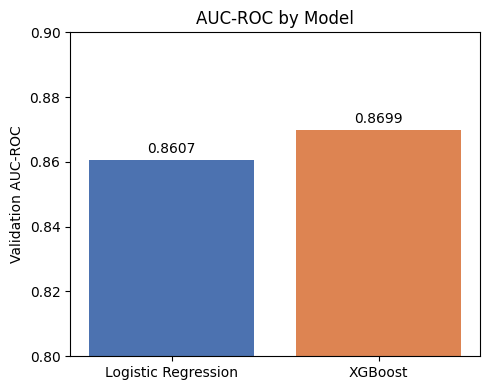

In [14]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'AUC-ROC': [auc_lr, auc_xgb]
})
print(comparison)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(comparison['Model'], comparison['AUC-ROC'], color=['#4C72B0', '#DD8452'])
ax.set_ylim(0.8, 0.9)
ax.set_ylabel('Validation AUC-ROC')
ax.set_title('AUC-ROC by Model')
for i, v in enumerate(comparison['AUC-ROC']):
    ax.text(i, v + 0.002, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()


**Result**: XGBoost improves the validation AUC-ROC from ~0.86 to ~0.87 over the logistic regression baseline. On this dataset, even top entries in the original Kaggle competition mostly cluster in the 0.86–0.87 range, so this performance is close to the practical ceiling. The fact that feature importance rankings largely agree between the two models adds confidence to the results.

## 7. SHAP Analysis

Feature importance only shows "how important" a feature is. SHAP goes further and shows "in which direction, and at what values" a feature pushes the prediction.


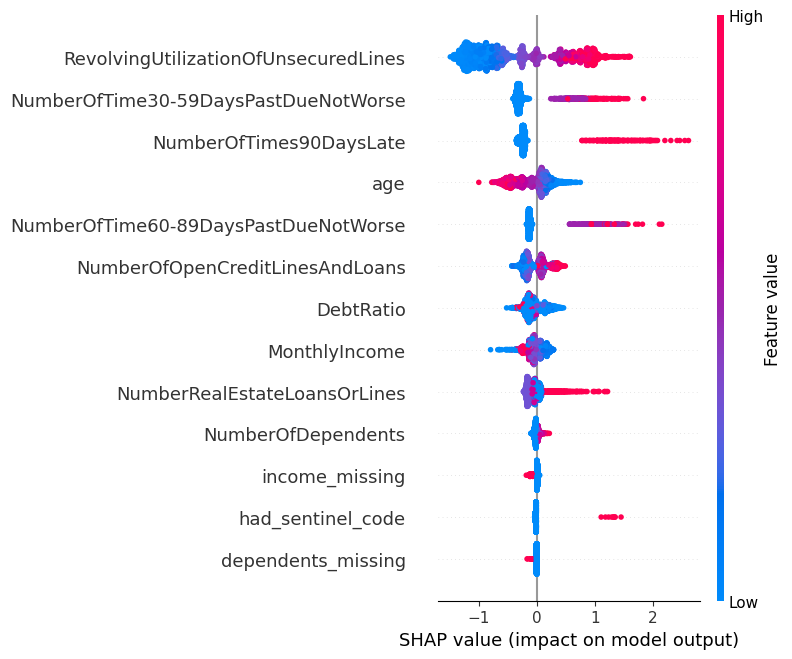

In [15]:
sample = X_val.sample(3000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, max_display=13, show=False)
plt.tight_layout()
plt.show()


**Key insights**:

1. **`RevolvingUtilizationOfUnsecuredLines` is the strongest and most consistent predictor.** High values (red points) are clearly pushed to the right (toward higher default risk).
2. **Delinquency history behaves like a threshold effect.** Borrowers with zero past delinquencies (blue points) cluster tightly on the left, but even a single delinquency event pushes the prediction sharply to the right.
3. **Older age is associated with lower risk** — plausibly reflecting accumulated credit history and financial stability.
4. **The engineered `had_sentinel_code` flag contributes meaningfully** — rows where this flag is 1 show a clear positive SHAP value, confirming that preserving the 96/98 anomaly as a flag (rather than discarding it) during cleaning was a valid decision.
5. `DebtRatio` and `MonthlyIncome` have relatively modest impact after capping/imputation — suggesting the cleaning step successfully suppressed distortion from extreme values.


## 8. Conclusion and Business Implications

- **Model performance**: XGBoost achieves a validation AUC-ROC of **0.87** and a recall of **0.78** for the default class.
- **Most important signals**: Credit line utilization and past delinquency history are by far the strongest predictors, consistent with traditional underwriting criteria used by banks.
- **Value of the cleaning process**: Rather than simply dropping or mean-imputing the raw data's anomalies (96/98 sentinel codes) and missing values (20% missing income), we traced the root cause of each issue through EDA and chose the cleaning order and method accordingly. The resulting engineered flag (`had_sentinel_code`) was confirmed via SHAP to meaningfully contribute to the model's predictions.
- **Considerations for real-world deployment**: At the current threshold (0.5), precision is only about 0.22, meaning a high false-positive rate. In production, the threshold should be re-optimized based on the quantified cost of missing a default versus the cost of incorrectly flagging a good customer.
